In [29]:
import kagglehub

path = kagglehub.dataset_download("tawfikelmetwally/employee-dataset")

print(path)

C:\Users\ASUS\.cache\kagglehub\datasets\tawfikelmetwally\employee-dataset\versions\1


In [33]:
import matplotlib.pyplot as plt
import os
import pandas as pd

In [30]:
print(os.listdir(path))

['Employee.csv']


In [3]:
file_path = path + "/Employee.csv"   # sửa đúng tên file

df = pd.read_csv(file_path)

print(df.head())

   Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
0  Bachelors         2017  Bangalore            3   34    Male          No   
1  Bachelors         2013       Pune            1   28  Female          No   
2  Bachelors         2014  New Delhi            3   38  Female          No   
3    Masters         2016  Bangalore            3   27    Male          No   
4    Masters         2017       Pune            3   24    Male         Yes   

   ExperienceInCurrentDomain  LeaveOrNot  
0                          0           0  
1                          3           1  
2                          2           0  
3                          5           1  
4                          2           1  


In [8]:
print(df.info())
print(df.describe())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB
None
       JoiningYear  PaymentTier          Age  ExperienceInCurrentDomain  \
count  4653.000000  4653.000000  4653.000000                4653.000000   
mean   2015.062970     2.698259    29.393295                   2.905652   
std    

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [19]:
# Hiển thị 10 nhân viên đầu tiên
df.head(10)
# lấy danh sách tất cả Education 
education_list = df['Education'].unique()
print(education_list)
# đếm số nhân viên theo từng Education
education_counts = df['Education'].value_counts()
print(education_counts)
# tìm nhân viên có paymentTier cao nhất 
max_payment_tier = df['PaymentTier'].idxmax()
print(max_payment_tier)

['Bachelors' 'Masters' 'PHD']
Education
Bachelors    3601
Masters       873
PHD           179
Name: count, dtype: int64
0


In [23]:
# lọc nhân viên PHD lương = 1 và Age từ 30 đến 35
phd_employees = df[(df['Education'] == 'PHD') & (df['PaymentTier'] == 1) & (df['Age'] >= 30) & (df['Age'] <= 35)]
print(phd_employees)

     Education  JoiningYear       City  PaymentTier  Age  Gender EverBenched  \
4553       PHD         2013       Pune            1   32  Female          No   
4556       PHD         2014  Bangalore            1   34  Female          No   

      ExperienceInCurrentDomain  LeaveOrNot  
4553                          0           1  
4556                          3           0  


In [24]:
# tìm lương trung bình theo từng Education
average_salary_by_education = df.groupby('Education')['PaymentTier'].mean()
print(average_salary_by_education)

Education
Bachelors    2.753124
Masters      2.465063
PHD          2.731844
Name: PaymentTier, dtype: float64


In [25]:
# Education nào trả lương cao nhất
df.groupby('Education')['PaymentTier'].mean().sort_values(ascending=False)

Education
Bachelors    2.753124
PHD          2.731844
Masters      2.465063
Name: PaymentTier, dtype: float64

<Axes: >

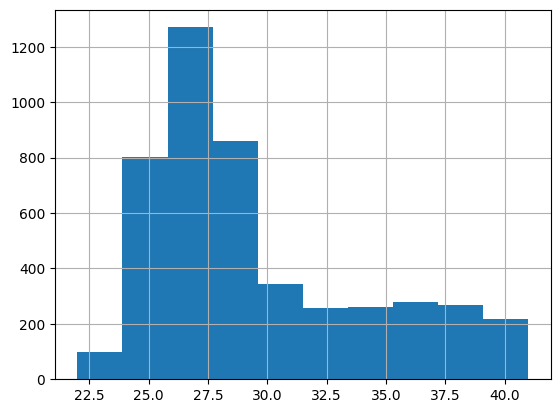

In [34]:
# phân bố độ tuổi của nhân viên
df['Age'].hist()

In [35]:
# Tương quan (correlation)

df.corr(numeric_only=True)

,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,LeaveOrNot
JoiningYear,1.000000,-0.096078,0.013165,-0.036525,0.181705
PaymentTier,-0.096078,1.000000,0.007631,0.018314,-0.197638
Age,0.013165,0.007631,1.000000,-0.134643,-0.051126
ExperienceInCurrentDomain,-0.036525,0.018314,-0.134643,1.000000,-0.030504
LeaveOrNot,0.181705,-0.197638,-0.051126,-0.030504,1.000000


In [36]:
# So sánh lương trung bình theo Education
if 'Education' in df.columns:
    salary_by_education = df.groupby('Education')['PaymentTier'].agg(['mean', 'min', 'max', 'count'])
    print("Lương trung bình theo trình độ học vấn:")
    print(salary_by_education)
    print(f"\nChênh lệch lương cao nhất - thấp nhất: {salary_by_education['mean'].max() - salary_by_education['mean'].min():.2f}")

Lương trung bình theo trình độ học vấn:
               mean  min  max  count
Education                           
Bachelors  2.753124    1    3   3601
Masters    2.465063    1    3    873
PHD        2.731844    1    3    179

Chênh lệch lương cao nhất - thấp nhất: 0.29


Tương quan giữa Kinh nghiệm và PaymentTier: 0.018

Lương trung bình theo nhóm kinh nghiệm:
                               mean  count
ExperienceInCurrentDomain                 
(-0.007, 1.4]              2.695509    913
(1.4, 2.8]                 2.674333   1087
(2.8, 4.2]                 2.707630   1717
(4.2, 5.6]                 2.712731    919
(5.6, 7.0]                 2.647059     17


C:\Users\ASUS\AppData\Local\Temp\ipykernel_1780\2613813586.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  experience_groups = df.groupby(pd.cut(df['ExperienceInCurrentDomain'], bins=5))['PaymentTier'].agg(['mean', 'count'])


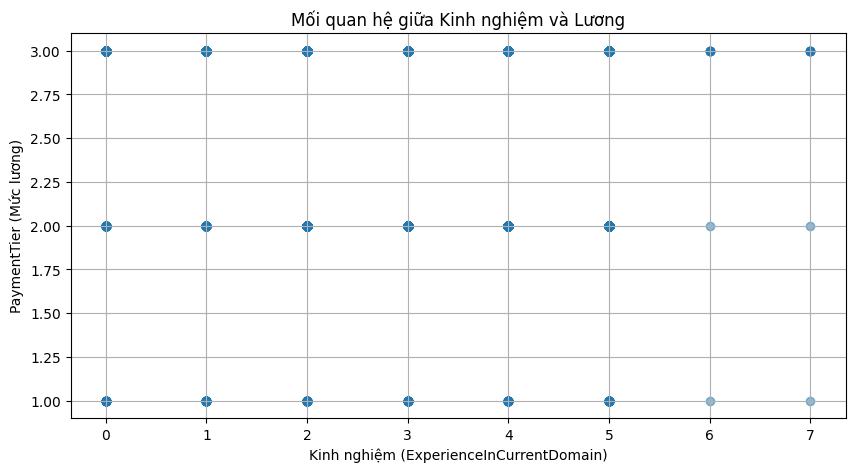

In [37]:
# Nhân viên làm lâu năm có lương cao hơn không?
import numpy as np
# cột kinh nghiệm ExperienceInCurrentDomain có thể dùng để đánh giá kinh nghiệm làm việc
correlation = df['ExperienceInCurrentDomain'].corr(df['PaymentTier'])

print(f"Tương quan giữa Kinh nghiệm và PaymentTier: {correlation:.3f}")

# Chia nhân viên theo kinh nghiệm và so sánh lương
experience_groups = df.groupby(pd.cut(df['ExperienceInCurrentDomain'], bins=5))['PaymentTier'].agg(
    ['mean', 'count'])
print("\nLương trung bình theo nhóm kinh nghiệm:")
print(experience_groups)

# Visualize
plt.figure(figsize=(10, 5))
plt.scatter(df['ExperienceInCurrentDomain'], df['PaymentTier'], alpha=0.5)
plt.xlabel('Kinh nghiệm (ExperienceInCurrentDomain)')
plt.ylabel('PaymentTier (Mức lương)')
plt.title('Mối quan hệ giữa Kinh nghiệm và Lương')
plt.grid(True)
plt.show()

In [46]:
# Education nào đông người nhưng lương thấp?
education_stats = df.groupby('Education').agg({
    'PaymentTier': ['mean', 'count']
}).round(2)

# Flatten column names để dễ sử dụng
education_stats.columns = ['average_salary', 'employee_count']

print("Phân tích theo Trình độ học vấn:")
print(education_stats.sort_values('average_salary'))

# Tìm trình độ học vấn có lương thấp nhất
min_salary_education = education_stats['average_salary'].idxmin()
min_salary_value = education_stats['average_salary'].min()
employee_count = education_stats.loc[min_salary_education, 'employee_count']

print(f"\n⚠️ Cảnh báo:")
print(f"Trình độ học vấn '{min_salary_education}' có lương thấp nhất ({min_salary_value:.2f})")
print(f"Số lượng nhân viên: {int(employee_count)}")

Phân tích theo Trình độ học vấn:
           average_salary  employee_count
Education                                
Masters              2.47             873
PHD                  2.73             179
Bachelors            2.75            3601

⚠️ Cảnh báo:
Trình độ học vấn 'Masters' có lương thấp nhất (2.47)
Số lượng nhân viên: 873


## Train model dự đoán nhân viên sẽ nghỉ việc

In [ ]:
# Chuyển đổi biến categorical (text) thành numeric (numbers)
# drop_first=True: bỏ cột đầu tiên để tránh multicollinearity (hiện tượng các biến độc lập tương quan cao với nhau)
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Tách dữ liệu thành X (features - các đặc trưng dự đoán) và y (target - mục tiêu là 'LeaveOrNot')
# X: tất cả các cột ngoại trừ 'LeaveOrNot'
# y: chỉ cột 'LeaveOrNot' (0: không nghỉ việc, 1: nghỉ việc)
X = df.drop('LeaveOrNot', axis=1)
y = df['LeaveOrNot']

In [ ]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành 2 phần:
# - test_size=0.2: 20% dữ liệu để kiểm tra, 80% để training
# - random_state=42: cố định seed để kết quả lặp lại được mỗi lần chạy
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
from sklearn.linear_model import LogisticRegression

# Tạo model Logistic Regression (phân loại nhị phân: sẽ nghỉ hay không)
# max_iter=1000: số lần lặp tối đa để tối ưu hóa tham số
lr_model = LogisticRegression(max_iter=1000)

# Huấn luyện model với dữ liệu training
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [63]:
# Xác định tầm quan trọng của từng feature trong mô hình Logistic Regression
# Coefficient: hệ số của mỗi feature (giá trị cao/âm thấp => ảnh hưởng lớn đến quyết định)
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

# In ra các features sắp xếp theo mức độ ảnh hưởng
print(importance)

                     Feature  Coefficient
4          Education_Masters     0.851920
7                  City_Pune     0.718921
9            EverBenched_Yes     0.597794
5              Education_PHD     0.017506
0                JoiningYear     0.000587
2                        Age    -0.018136
3  ExperienceInCurrentDomain    -0.052771
1                PaymentTier    -0.359928
6             City_New Delhi    -0.426876
8                Gender_Male    -0.862092


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Dự đoán trên tập test
y_pred = lr_model.predict(X_test)

# In kết quả đánh giá:
# - Accuracy: tỷ lệ dự đoán đúng (0-1)
# - Classification Report: chi tiết precision, recall, f1-score cho mỗi class
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8539205155746509
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       610
           1       0.82      0.74      0.78       321

    accuracy                           0.85       931
   macro avg       0.84      0.83      0.83       931
weighted avg       0.85      0.85      0.85       931



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Tạo model Random Forest (một nhóm cây quyết định ngẫu nhiên)
# Random Forest thường cho độ chính xác cao hơn Logistic Regression
rf_model = RandomForestClassifier()

# Huấn luyện model với dữ liệu training
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Xác định tầm quan trọng của từng feature trong mô hình Random Forest
# feature_importances_: đo lường độ quan trọng của mỗi feature (0-1)
# Giá trị cao hơn = feature ảnh hưởng lớn hơn đến quyết định của model
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# In ra các features sắp xếp theo mức độ quan trọng (cao nhất trước)
print(importance)

                     Feature  Importance
0                JoiningYear    0.316429
2                        Age    0.177253
1                PaymentTier    0.107767
3  ExperienceInCurrentDomain    0.090169
8                Gender_Male    0.086445
7                  City_Pune    0.086027
4          Education_Masters    0.078026
6             City_New Delhi    0.026150
9            EverBenched_Yes    0.020287
5              Education_PHD    0.011448
